# Re-predict GEDI L4A AGBD from stored `xvar` using the revised R003 EBT_SA model

This notebook applies the revised R003 `'EBT_SA'` biomass model to a Version 3 
(V003) GEDI L4A granule for South American (SA) forest strata, **without** 
re-deriving the model's predictors (relative height, RH) from the Level L2A 
GEDI product.

There are two prediction strata that use the `'EBT_SA'` model: `'EBT_SA'` and
`'DBT_SA'`. The code below finds this from the granule's own
`ANCILLARY/model_data` (looking for `model_name == 'EBT_SA'`) rather than
hardcoding the pair.

Each GEDI shot already stores its fully-built (offset-applied, transformed)
predictor design matrix in the `xvar` dataset, and the model actually applied
when the granule was produced is recorded per prediction stratum in
`ANCILLARY/model_data`. There is no need to go back to the L2A product for re-deriving 
the RH metrics and re-predicting AGBD with new model coefficients is just the following steps:

1. Find all footprints where `predict_stratum` was `'EBT_SA'` or `'DBT_SA'`
   when the granule was produced.
2. Confirm the predictor definition (`rh_index`, `predictor_id`,
   `x_transform`) for that stratum still matches the revised model —
   this is what makes reusing `xvar` valid instead of a coincidence.
3. Re-apply `agbd_t = [1, xvar] @ par_new`, back-transform, and re-apply the
   bias correction.

## Prerequisites

- **Granule file**: this notebook expects the L4A `.h5` granule in the same directory (see `GRANULE_FILE` below). Adjust 
  the path if yours lives elsewhere.
- **Packages**: `h5py`, `numpy`, `matplotlib`.


In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

NODATA = -9999.0

# A V003 L4A granule (Amazon basin overpass) with a large EBT_SA population
GRANULE_FILE = './GEDI04_A_2022314110220_O22155_04_T02087_02_004_01_V003.h5'

# The model_name (== fit_stratum bucket in the selection JSON) whose coefficients
# were revised on 2026-07-22
CHANGED_MODEL_NAME = 'EBT_SA'

# NEW_MODEL holds the revised coefficients. Shared refit coefficients, 
# from issgedi_l4a_r003_estimators_20260722.json
# group 4 / EBT_SA / selection 3 (identical to selection 4, used by DBT_SA --
# both prediction strata now share this exact fit)
NEW_MODEL = {
    'rh_index': [50, 98],
    'predictor_id': [1, 2],
    'x_transform': 'sqrt',
    'y_transform': 'sqrt',
    'bias_correction_name': 'Snowdon',
    'bias_correction_value': 1.15323996418645,
    'par': [-133.884363713764, 6.95698142185319, 6.28656682203761],
    'vcov': [2.50305363959644, -0.111702554712149, -0.114315207874669,
             -0.111702554712149, 0.0654051766999497, -0.0523471595323726,
             -0.114315207874669, -0.0523471595323726, 0.0598715899876015],
    'rse': 3.53298787494478,
    'dof': 3485,
    'response_max_value': 1578.0,
    'predictor_max_value': [12.2270192606375, 12.7730184373154],
}


In [2]:
# The EBT_SA model is a square-root model with a Snowdon bias correction --
# hardcoded rather than dispatched on NEW_MODEL['y_transform']/['bias_correction_name'],
# since this is the only model this notebook ever applies.
def back_transform(agbd_t):
    return agbd_t ** 2


def apply_bias_correction(agbd, value):
    return agbd * value


def get_baked_in_models(fid):
    """Per-stratum model actually used to produce this granule -- the model_name
    it was routed to, plus its predictor definition (rh_index/predictor_id/
    x_transform) -- read from ANCILLARY/model_data."""
    md = fid['ANCILLARY/model_data'][()]
    models = {}
    for row in md:
        stratum = row['predict_stratum'].decode()
        npar = int(row['npar'])
        models[stratum] = {
            'model_name': row['model_name'].decode(),
            'rh_index': [int(v) for v in row['rh_index'][:npar - 1]],
            'predictor_id': [int(v) for v in row['predictor_id'][:npar - 1]],
            'x_transform': row['x_transform'].decode(),
        }
    return models


def get_compatible_strata(baked_in_models):
    """Prediction strata routed through the revised model, restricted to those
    whose predictor definition is unchanged from what's baked into the granule."""
    compatible = []
    for stratum, baked_in in baked_in_models.items():
        if baked_in['model_name'] != CHANGED_MODEL_NAME:
            continue
        ok = (baked_in['rh_index'] == NEW_MODEL['rh_index'] and
              baked_in['predictor_id'] == NEW_MODEL['predictor_id'] and
              baked_in['x_transform'] == NEW_MODEL['x_transform'])
        if ok:
            compatible.append(stratum)
        else:
            print(f'  SKIPPED {stratum}: predictor definition changed, xvar reuse invalid')
    return compatible


def recompute_agbd_from_xvar(xvar, predict_stratum, compatible_strata):
    """Re-predict AGBD from a stored predictor matrix using the revised model."""
    agbd_new = np.full(xvar.shape[0], NODATA, dtype=np.float32)
    npar = len(NEW_MODEL['par'])

    for stratum in compatible_strata:
        idx = np.nonzero(predict_stratum == stratum)[0]
        if idx.shape[0] == 0:
            continue
        xvar_s = xvar[idx, 0:npar - 1]
        valid = np.all(xvar_s != NODATA, axis=1)
        if not valid.any():
            continue

        predictors = np.ones((valid.sum(), npar), dtype=np.float64)
        predictors[:, 1:npar] = xvar_s[valid]
        agbd_t = predictors @ np.array(NEW_MODEL['par'])
        agbd = back_transform(agbd_t)
        agbd = apply_bias_correction(agbd, NEW_MODEL['bias_correction_value'])
        agbd_new[idx[valid]] = agbd

    return agbd_new


## Read the granule and re-predict AGBD per beam

Only `xvar`, `predict_stratum`, `agbd` (old estimate), `l4a_quality_flag_rel3`,
`lat_lowestmode`/`lon_lowestmode`, and `ANCILLARY/model_data` are needed.


In [3]:
agbd_old_list, agbd_new_list, quality_list, stratum_list = [], [], [], []
lon_list, lat_list = [], []

with h5py.File(GRANULE_FILE, 'r') as fid:
    beams = [b for b in fid.keys() if b.startswith('BEAM')]
    baked_in_models = get_baked_in_models(fid)

    print(f"Finding strata routed through the '{CHANGED_MODEL_NAME}' model:")
    compatible_strata = get_compatible_strata(baked_in_models)

    for beam in beams:
        xvar = fid[f'{beam}/xvar'][()]
        predict_stratum = np.array([s.decode() for s in fid[f'{beam}/predict_stratum'][()]])
        agbd_old = fid[f'{beam}/agbd'][()]
        quality_flag = fid[f'{beam}/l4a_quality_flag_rel3'][()]
        lon = fid[f'{beam}/lon_lowestmode'][()]
        lat = fid[f'{beam}/lat_lowestmode'][()]

        agbd_new = recompute_agbd_from_xvar(xvar, predict_stratum, compatible_strata)

        agbd_old_list.append(agbd_old)
        agbd_new_list.append(agbd_new)
        quality_list.append(quality_flag)
        stratum_list.append(predict_stratum)
        lon_list.append(lon)
        lat_list.append(lat)

agbd_old = np.concatenate(agbd_old_list)
agbd_new = np.concatenate(agbd_new_list)
quality_flag = np.concatenate(quality_list)
predict_stratum = np.concatenate(stratum_list)
lon = np.concatenate(lon_list)
lat = np.concatenate(lat_list)

valid_coord = (lon > -180) & (lon < 180)
print(f'Granule: {GRANULE_FILE.split("/")[-1]}')
print(f'Bounding box: lon [{lon[valid_coord].min():.2f}, {lon[valid_coord].max():.2f}], '
      f'lat [{lat[valid_coord].min():.2f}, {lat[valid_coord].max():.2f}]  (South America)')
print(f'Total shots: {agbd_old.shape[0]}')
print(f'Strata updated: {sorted(compatible_strata)}')


Finding strata routed through the 'EBT_SA' model:
Granule: GEDI04_A_2022314110220_O22155_04_T02087_02_004_01_V003.h5
Bounding box: lon [-80.99, -51.52], lat [-34.14, 0.28]  (South America)
Total shots: 681626
Strata updated: ['DBT_SA', 'EBT_SA']


## Effect of the revised estimators, by prediction stratum

Restricted to `l4a_quality_flag_rel3 == 1` shots.


In [4]:
quality = (quality_flag == 1) & (agbd_old != NODATA) & (agbd_new != NODATA)
print(f'Quality shots: {quality.sum()} / {agbd_old.shape[0]}')
print()
print(f'{"stratum":10s} {"n":>8s} {"mean_before":>12s} {"mean_after":>12s} {"mean_delta":>12s}')
for stratum in sorted(np.unique(predict_stratum[quality])):
    m = quality & (predict_stratum == stratum)
    delta = agbd_new[m] - agbd_old[m]
    print(f'{stratum:10s} {m.sum():8d} {agbd_old[m].mean():12.2f} {agbd_new[m].mean():12.2f} {delta.mean():12.3f}')

print()
print(f'Overall mean AGBD before: {agbd_old[quality].mean():.2f} Mg/ha')
print(f'Overall mean AGBD after:  {agbd_new[quality].mean():.2f} Mg/ha')


Quality shots: 13035 / 681626

stratum           n  mean_before   mean_after   mean_delta
DBT_SA          780         7.43         1.67       -5.758
EBT_SA        12255        82.75        74.35       -8.395

Overall mean AGBD before: 78.24 Mg/ha
Overall mean AGBD after:  70.00 Mg/ha


### Distribution of the per-shot change

The histogram shows the per-shot AGBD change (`after - before`). The dashed
line marks the mean. A distribution sitting mostly left of zero confirms the
revision reduces biomass estimates across the quality-flagged shots, not just
on average.

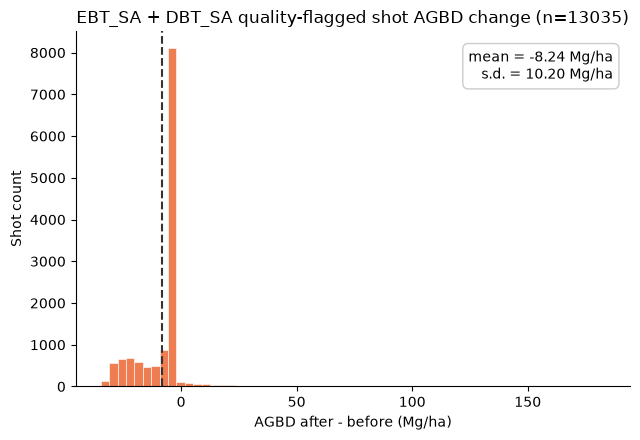

In [5]:
COLOR_DELTA = '#eb6834'  # categorical slot 2 (orange)

before = agbd_old[quality]
after = agbd_new[quality]
delta = after - before
delta_mean, delta_sd = delta.mean(), delta.std()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.hist(delta, bins=60, color=COLOR_DELTA, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(delta_mean, color='0.2', linewidth=1.5, linestyle='--')
ax.set_xlabel('AGBD after - before (Mg/ha)')
ax.set_ylabel('Shot count')
ax.set_title(f'EBT_SA + DBT_SA quality-flagged shot AGBD change (n={quality.sum()})')
ax.text(0.97, 0.95, f'mean = {delta_mean:.2f} Mg/ha\ns.d. = {delta_sd:.2f} Mg/ha',
        transform=ax.transAxes, va='top', ha='right',
        bbox=dict(facecolor='white', edgecolor='0.8', boxstyle='round,pad=0.4'))
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()


## Where in the distribution is the change?

The Q-Q plot compares the before/after AGBD distributions percentile-by-percentile against the 1:1 line. Points falling below the line mean the
revised estimate is lower at that percentile; the growing gap toward the high
end shows the reduction is largest for the highest-biomass shots.

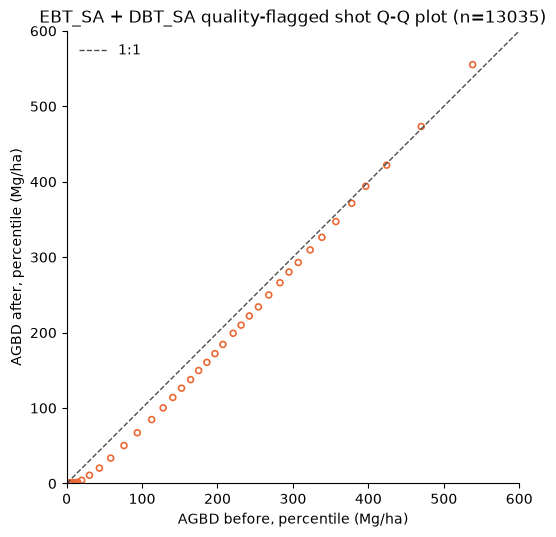

In [6]:
percentiles = np.arange(1, 100)
before_q = np.percentile(before, percentiles)
after_q = np.percentile(after, percentiles)
lim = max(before_q.max(), after_q.max(), 600)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, lim], [0, lim], color='0.3', linewidth=1, linestyle='--', label='1:1')
ax.scatter(before_q, after_q, s=18, facecolors='none', edgecolors=COLOR_DELTA, linewidths=1.2)
ax.set_xlabel('AGBD before, percentile (Mg/ha)')
ax.set_ylabel('AGBD after, percentile (Mg/ha)')
ax.set_title(f'EBT_SA + DBT_SA quality-flagged shot Q-Q plot (n={quality.sum()})')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()
